
**Course:** Aprendizagem Profunda (Deep Learning)  
**Programme:** Mestrado em Engenharia Informática – Data Engineering, ISEP 2025/2026

---

### Research Questions

| # | Question |
|---|----------|
| **RQ1** | How does the choice of RNN cell type (LSTM vs. SimpleRNN) affect forecasting performance? |
| **RQ2** | What is the impact of different temporal window sizes on prediction capability? |
| **RQ3** | How do different combinations of layers and window sizes influence RMSLE, quality and robustness? |

### Dataset
- **Source:** Jena Climate 2009–2016 (Max Planck Institute for Biogeochemistry)

---
## 0. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.20.0
NumPy      : 2.3.4
Pandas     : 2.3.3
GPU available: False


In [2]:
import tensorflow as tf

def rmsle(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

# model.compile(optimizer='adam', loss='mse', metrics=[rmsle])
print('RMSLE metric defined.')

RMSLE metric defined.


## 1. Data Loading

### Carregamento e Inspeção Inicial dos Dados

Nesta etapa foi efetuado o carregamento do dataset. Após a leitura do ficheiro CSV, verificou-se a dimensão do conjunto de dados, que contém **420 551 observações** e **15 variáveis meteorológicas**. Foram também listados os nomes das colunas disponíveis, incluindo parâmetros como temperatura, pressão atmosférica, humidade relativa, velocidade do vento e direção do vento. 

Por fim, visualizaram-se as três primeiras linhas do dataset com o objetivo de confirmar que os dados foram importados corretamente e compreender a sua estrutura antes de iniciar o pré-processamento e a construção do modelo RNN.

In [5]:
DATA_PATH = 'jena_climate_2009_2016.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (420551, 15)
Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


### Conversão da Data e Análise Inicial dos Dados

Foi convertida a coluna **Date Time** para o formato datetime e definida como índice do dataset. Os dados foram ordenados por data, verificou-se a presença de valores em falta e calcularam-se estatísticas descritivas para analisar a distribuição das variáveis.

In [6]:
# Parse datetime and set as index
df_raw['Date Time'] = pd.to_datetime(df_raw['Date Time'], format='%d.%m.%Y %H:%M:%S')
df_raw = df_raw.set_index('Date Time').sort_index()

print(f'Date range : {df_raw.index[0]}  →  {df_raw.index[-1]}')
print(f'Total rows : {len(df_raw):,}')
print(f'\nMissing values per column:')
print(df_raw.isnull().sum())
print(f'\nBasic statistics:')
df_raw.describe().round(2)

Date range : 2009-01-01 00:10:00  →  2017-01-01 00:00:00
Total rows : 420,551

Missing values per column:
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

Basic statistics:


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,989.21,9.45,283.49,4.96,76.01,13.58,9.53,4.04,6.02,9.64,1216.06,1.70,3.06,174.74
std,8.36,8.42,8.50,6.73,16.48,7.74,4.18,4.90,2.66,4.24,39.98,65.45,69.02,86.68
min,913.60,-23.01,250.60,-25.01,12.95,0.95,0.79,0.00,0.50,0.80,1059.45,-9999.00,-9999.00,0.00
25%,984.20,3.36,277.43,0.24,65.21,7.78,6.21,0.87,3.92,6.29,1187.49,0.99,1.76,124.90
50%,989.58,9.42,283.47,5.22,79.30,11.82,8.86,2.19,5.59,8.96,1213.79,1.76,2.96,198.10
75%,994.72,15.47,289.53,10.07,89.40,17.60,12.35,5.30,7.80,12.49,1242.77,2.86,4.74,234.10
max,1015.35,37.28,311.34,23.11,100.00,63.77,28.32,46.01,18.13,28.82,1393.54,28.49,23.50,360.00


## 2. Exploratory Data Analysis (EDA)

Realizei uma análise da variável **temperatura do ar (T (degC))**. Primeiro, foi representada a evolução da temperatura ao longo de todo o período disponível (2009–2016). De seguida, foi analisado em detalhe o ano de 2013 como exemplo representativo, permitindo observar com maior clareza as variações sazonais e as flutuações da temperatura ao longo de um ano.

Por fim, foi construído um histograma da temperatura e calculadas estatísticas descritivas, incluindo a média e a mediana, para compreender a distribuição dos valores.

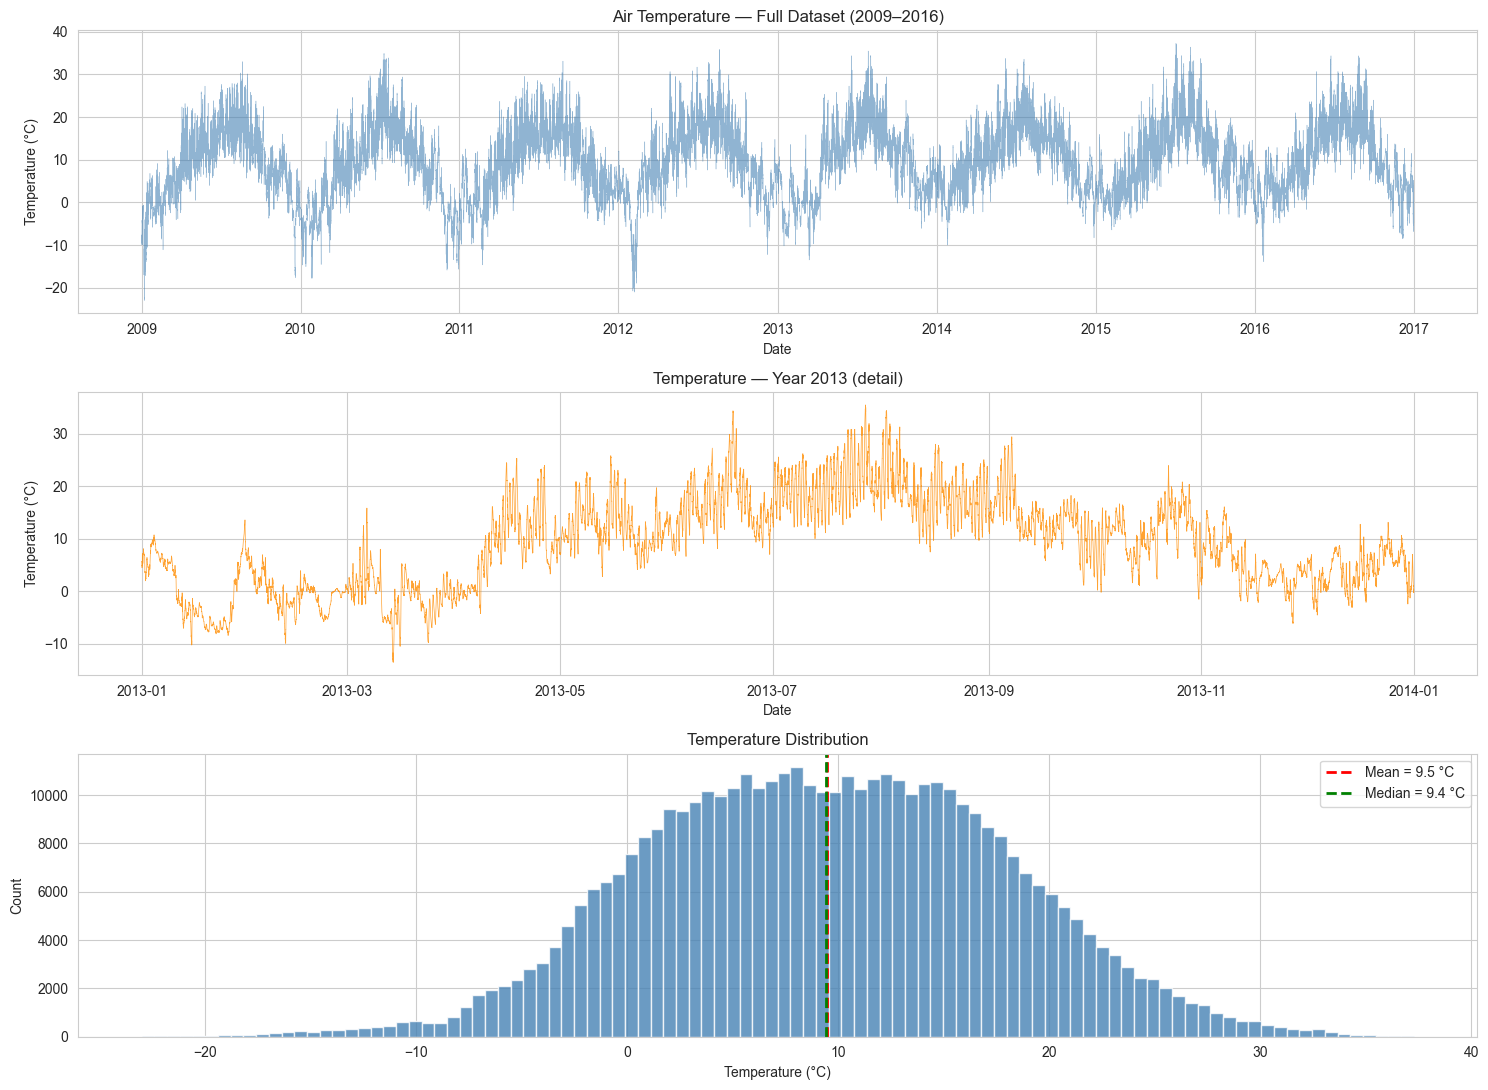

Temperature statistics:
count    420551.00
mean          9.45
std           8.42
min         -23.01
25%           3.36
50%           9.42
75%          15.47
max          37.28
Name: T (degC), dtype: float64


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# 1 — Full time series
axes[0].plot(df_raw.index, df_raw['T (degC)'],
             alpha=0.6, linewidth=0.3, color='steelblue')
axes[0].set_title('Air Temperature — Full Dataset (2009–2016)', fontsize=12)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_xlabel('Date')

# 2 — One representative year
mask_2013 = df_raw.index.year == 2013
axes[1].plot(df_raw.index[mask_2013], df_raw['T (degC)'][mask_2013],
             alpha=0.8, linewidth=0.5, color='darkorange')
axes[1].set_title('Temperature — Year 2013 (detail)', fontsize=12)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Date')

# 3 — Distribution
axes[2].hist(df_raw['T (degC)'], bins=100, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[2].axvline(df_raw['T (degC)'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {df_raw["T (degC)"].mean():.1f} °C')
axes[2].axvline(df_raw['T (degC)'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Median = {df_raw["T (degC)"].median():.1f} °C')
axes[2].set_title('Temperature Distribution', fontsize=12)
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Temperature statistics:')
print(df_raw['T (degC)'].describe().round(2))

- Existe um padrão sazonal muito evidente (temperaturas mais altas no verão e mais baixas no inverno).
- A temperatura média é aproximadamente 9,5 °C.
- A média e a mediana são muito semelhantes (9,5 °C e 9,4 °C), indicando uma distribuição relativamente equilibrada.
- Os valores observados variam aproximadamente entre -23 °C e 37 °C.

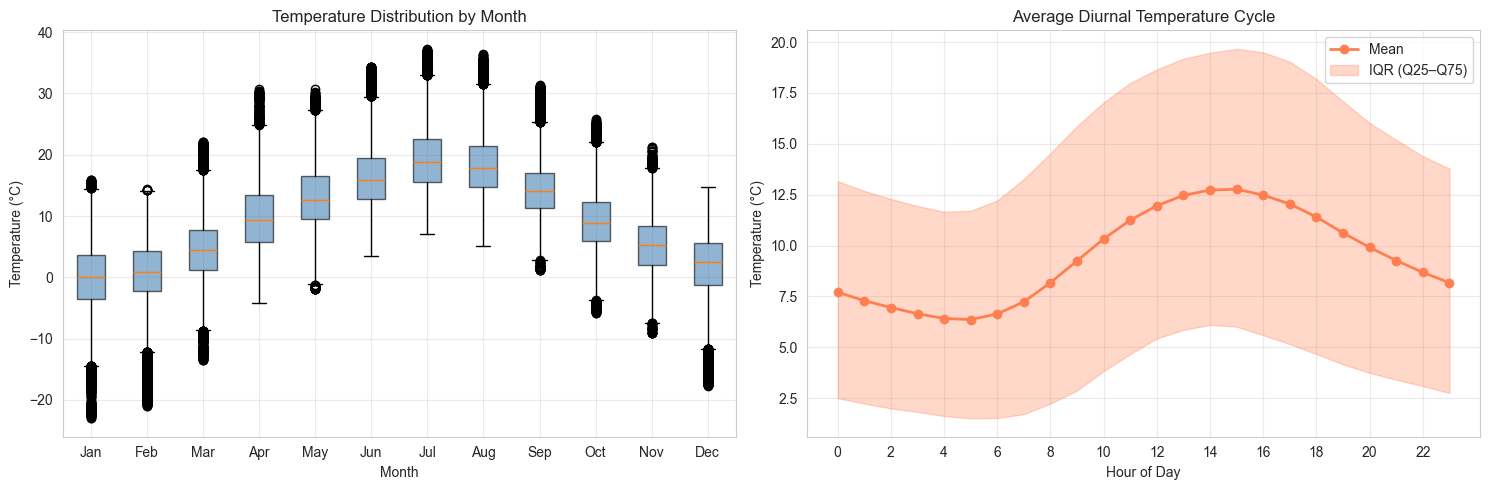

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Monthly boxplot
df_raw['month'] = df_raw.index.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_data = [df_raw['T (degC)'][df_raw['month'] == m].values for m in range(1, 13)]
axes[0].boxplot(monthly_data, labels=month_labels, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Temperature Distribution by Month', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, alpha=0.4)

# Hourly average (diurnal cycle)
df_raw['hour'] = df_raw.index.hour
hourly_mean = df_raw.groupby('hour')['T (degC)'].mean()
hourly_q25  = df_raw.groupby('hour')['T (degC)'].quantile(0.25)
hourly_q75  = df_raw.groupby('hour')['T (degC)'].quantile(0.75)

axes[1].plot(hourly_mean.index, hourly_mean.values,
             marker='o', color='coral', linewidth=2, label='Mean')
axes[1].fill_between(hourly_mean.index, hourly_q25, hourly_q75,
                     alpha=0.3, color='coral', label='IQR (Q25–Q75)')
axes[1].set_title('Average Diurnal Temperature Cycle', fontsize=12)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('eda_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

Foi analisada a sazonalidade da temperatura através de duas perspetivas. Primeiro, foi construído um boxplot mensal para comparar a distribuição das temperaturas ao longo dos diferentes meses do ano. Em seguida, foi calculado o ciclo diário médio da temperatura, agrupando os registos por hora do dia e representando a média e a variabilidade dos valores observados.

Pelos gráficos percebe-se que:

- Os meses de verão (junho, julho e agosto) apresentam temperaturas **mais elevadas**.
- Os meses de inverno (dezembro, janeiro e fevereiro) apresentam temperaturas **mais baixas**.
- Ao longo do dia, a temperatura tende a atingir valores **mínimos durante a madrugada** e **máximos durante a tarde**.

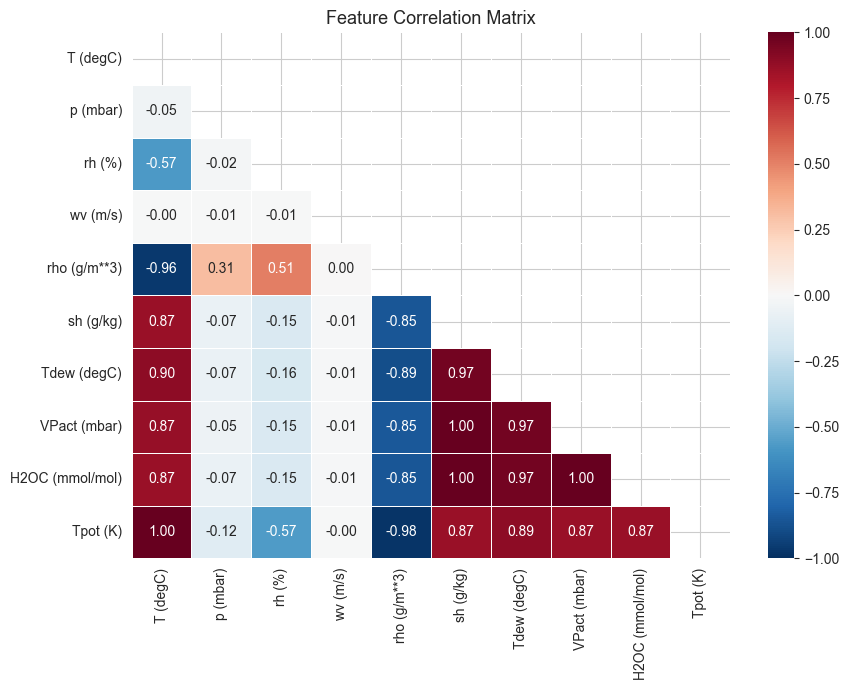

Top correlations with T (degC):
Tpot (K)           0.997
rho (g/m**3)       0.963
Tdew (degC)        0.896
VPact (mbar)       0.868
H2OC (mmol/mol)    0.867
sh (g/kg)          0.867
rh (%)             0.572
p (mbar)           0.045
wv (m/s)           0.005
Name: T (degC), dtype: float64


In [14]:
# Correlation heatmap — select numeric columns of interest
corr_cols = [
    'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'rho (g/m**3)', 'sh (g/kg)', 'Tdew (degC)', 'VPact (mbar)', 'H2OC (mmol/mol)', 'Tpot (K)'
]
corr_df = df_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            annot_kws={'size': 10}, vmin=-1, vmax=1,
            linewidths=0.5)

ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with T (degC):')
temp_corr = corr_df['T (degC)'].drop('T (degC)').abs().sort_values(ascending=False)
print(temp_corr.round(3))

Foi calculada a matriz de correlação entre a temperatura e outras variáveis meteorológicas selecionadas. 

Para isso, foram utilizados os coeficientes de correlação de Pearson e os resultados foram representados através de um heatmap. Posteriormente, foram identificadas e apresentadas as variáveis com maior correlação com a temperatura, permitindo compreender quais os atributos potencialmente mais relevantes para a previsão da variável alvo.

## 3. Preprocessing

### Steps
1. **Feature selection** — seleção de variáveis fisicamente relevantes para o problema, excluindo colunas derivadas redundantes, como **VPmax** e **VPdef**. Estas foram removidas devido à sua elevada redundância com outras variáveis de humidade e pressão de vapor, reduzindo a multicolinearidade do conjunto de dados

2. **Bad-value handling** — substituição dos valores inválidos `wv = -9999` (erro do sensor) por valores nulos (*NaN*) e preenchimento utilizando o valor válido anterior (*forward-fill*).

3. **Cyclical encoding** — a direção do vento (0°–360°) foi codificada através das componentes seno e cosseno `(sin, cos)` para preservar a sua natureza circular.

4. **Temporal features** — foram criadas variáveis temporais cíclicas para a hora do dia e para o dia do ano, permitindo capturar padrões diários e sazonais.

5. **Downsampling** — redução da frequência dos dados de registos a cada 10 minutos para registos horários através da agregação pela média (compressão aproximada de 6×).

6. **Normalisation** — **MinMaxScaler** ajustado apenas aos dados de treino e posteriormente aplicado aos conjuntos de validação e teste, garantindo que os valores ficam no intervalo `[0, 1]` e respeitam o requisito de não negatividade do RMSLE.

7. **Sequence construction** — construção de sequências através de uma janela deslizante de tamanho **W**, gerando entradas `X ∈ ℝ^(W × F)` e uma variável alvo `y = T[t + 24]`, correspondente à temperatura prevista para 24 horas no futuro.

8. **Chronological split** — divisão cronológica dos dados em **70% para treino**, **15% para validação** e **15% para teste**, sem embaralhamento dos registos, evitando assim *data leakage*.

In [12]:
# Feature selection & bad-value handling 
RAW_FEATURES = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'rho (g/m**3)', 'sh (g/kg)', 'wd (deg)']
TARGET = 'T (degC)'

df = df_raw[RAW_FEATURES].copy()

# Sensor error: wv == -9999 means missing
df['wv (m/s)'] = df['wv (m/s)'].replace(-9999.0, np.nan)

# Forward-fill then backward-fill for any remaining NaN
df = df.ffill().bfill()

print(f'Missing values after cleaning: {df.isnull().sum().sum()}')
print(f'Shape: {df.shape}')
df.describe().round(2)

Missing values after cleaning: 0
Shape: (420551, 7)


,T (degC),p (mbar),rh (%),wv (m/s),rho (g/m**3),sh (g/kg),wd (deg)
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,9.45,989.21,76.01,2.13,1216.06,6.02,174.74
std,8.42,8.36,16.48,1.54,39.98,2.66,86.68
min,-23.01,913.60,12.95,0.00,1059.45,0.50,0.00
25%,3.36,984.20,65.21,0.99,1187.49,3.92,124.90
50%,9.42,989.58,79.30,1.76,1213.79,5.59,198.10
75%,15.47,994.72,89.40,2.86,1242.77,7.80,234.10
max,37.28,1015.35,100.00,28.49,1393.54,18.13,360.00


Com base na análise de correlação, foram removidas as variáveis **Tpot (K)**, **Tdew (degC)**, **VPmax (mbar)**, **VPact (mbar)**, **VPdef (mbar)** e **H2OC (mmol/mol)** por apresentarem elevada redundância relativamente a outras variáveis selecionadas. Em particular, **Tpot (K)** mostrou uma correlação praticamente perfeita com a temperatura, enquanto **VPact (mbar)**, **H2OC (mmol/mol)** e **Tdew (degC)** apresentaram correlações muito elevadas com as variáveis relacionadas com a humidade. 

A remoção destas variáveis permitiu reduzir a multicolinearidade do conjunto de dados, simplificar o modelo e evitar a utilização de informação repetida, mantendo apenas os atributos considerados mais relevantes e distintos para a previsão da temperatura.

In [15]:
# Cyclical encoding 
# Wind direction: 0°–360° is circular - encode as (sin, cos)
df['wd_sin'] = np.sin(2 * np.pi * df['wd (deg)'] / 360.0)
df['wd_cos'] = np.cos(2 * np.pi * df['wd (deg)'] / 360.0)
df = df.drop(columns=['wd (deg)'])

# Time-based cyclical features
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24.0)
df['doy_sin']  = np.sin(2 * np.pi * df.index.dayofyear / 365.0)
df['doy_cos']  = np.cos(2 * np.pi * df.index.dayofyear / 365.0)

# Hourly downsampling 
df_hourly = df.resample('h').mean().dropna()

print(f'Original  : {len(df):,}  records (10-min)')
print(f'Hourly    : {len(df_hourly):,}  records (1-hour)')
print(f'Features  : {df_hourly.columns.tolist()}')
print(f'N features: {df_hourly.shape[1]}')
df_hourly.head(3)

Original  : 420,551  records (10-min)
Hourly    : 70,041  records (1-hour)
Features  : ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'rho (g/m**3)', 'sh (g/kg)', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
N features: 12


,T (degC),p (mbar),rh (%),wv (m/s),rho (g/m**3),sh (g/kg),wd_sin,wd_cos,hour_sin,hour_cos,doy_sin,doy_cos
Date Time,,,,,,,,,,,,
2009-01-01 00:00:00,-8.304000,996.528,93.780000,0.520000,1309.196000,1.910000,0.086357,-0.874474,0.000000,1.000000,0.017213,0.999852
2009-01-01 01:00:00,-8.065000,996.525,93.933333,0.316667,1307.981667,1.951667,0.100133,-0.901708,0.258819,0.965926,0.017213,0.999852
2009-01-01 02:00:00,-8.763333,996.745,93.533333,0.248333,1311.816667,1.836667,-0.185926,-0.759236,0.500000,0.866025,0.017213,0.999852


A direção do vento foi convertida para as componentes seno e cosseno de forma a preservar a sua natureza circular. 

Foram também criadas variáveis temporais cíclicas para representar a hora do dia e o dia do ano, permitindo capturar padrões diários e sazonais. 

Por fim, os dados foram agregados para frequência horária através da média dos registos de 10 minutos, reduzindo o volume de dados e o ruído presente nas medições.

In [16]:
# --- Chronological train / validation / test split ---------------------------
N = len(df_hourly)
TRAIN_END = int(N * 0.70)
VAL_END   = int(N * 0.85)

train_df = df_hourly.iloc[:TRAIN_END]
val_df   = df_hourly.iloc[TRAIN_END:VAL_END]
test_df  = df_hourly.iloc[VAL_END:]

print(f'Train : {len(train_df):>6,} hours  ({len(train_df)/N*100:.1f}%)')
print(f'  {train_df.index[0]}  →  {train_df.index[-1]}')
print(f'Val   : {len(val_df):>6,} hours  ({len(val_df)/N*100:.1f}%)')
print(f'  {val_df.index[0]}  →  {val_df.index[-1]}')
print(f'Test  : {len(test_df):>6,} hours  ({len(test_df)/N*100:.1f}%)')
print(f'  {test_df.index[0]}  →  {test_df.index[-1]}')

# --- MinMax normalisation: fit on train only ---------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df).astype(np.float32)
val_scaled   = scaler.transform(val_df).astype(np.float32)
test_scaled  = scaler.transform(test_df).astype(np.float32)

TARGET_IDX = list(df_hourly.columns).index(TARGET)
N_FEATURES = df_hourly.shape[1]
print(f'\nTarget "{TARGET}" at index {TARGET_IDX}')
print(f'Number of features : {N_FEATURES}')
print(f'Scaled train range : [{train_scaled.min():.3f}, {train_scaled.max():.3f}]')

Train : 49,028 hours  (70.0%)
  2009-01-01 00:00:00  →  2014-08-05 19:00:00
Val   : 10,506 hours  (15.0%)
  2014-08-05 20:00:00  →  2015-10-18 04:00:00
Test  : 10,507 hours  (15.0%)
  2015-10-18 05:00:00  →  2017-01-01 00:00:00

Target "T (degC)" at index 0
Number of features : 12
Scaled train range : [0.000, 1.000]


Os dados foram divididos cronologicamente em conjuntos de treino (70%), validação (15%) e teste (15%), preservando a ordem temporal das observações e evitando data leakage. 

De seguida, foi aplicada a normalização Min-Max, ajustada apenas aos dados de treino e posteriormente aplicada aos conjuntos de validação e teste. Por fim, foi identificada a posição da variável alvo (temperatura) para utilização na construção das sequências temporais.

In [18]:
def create_sequences(data, window_size, horizon=24):
    
    X, y = [], []
    total = len(data) - window_size - horizon + 1
    for i in range(total):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon - 1, TARGET_IDX])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


HORIZON = 24  # predict temperature 24 hours ahead
print(f'Forecasting horizon : {HORIZON} hours')

Forecasting horizon : 24 hours


Foi criada uma função para gerar sequências temporais através de uma janela deslizante. 

Cada sequência utiliza um conjunto de observações passadas como entrada e associa-lhes a temperatura observada 24 horas no futuro como variável alvo. Este procedimento converte a série temporal num formato adequado para o treino dos modelos RNN e LSTM.

In [21]:
# Build datasets for multiple window sizes
WINDOW_SIZES = {
    '24h': 24,
    '48h': 48,
    '168h': 168
}
datasets = {}

for name, W in WINDOW_SIZES.items():
    X_tr, y_tr = create_sequences(train_scaled, W, HORIZON)
    X_va, y_va = create_sequences(val_scaled,   W, HORIZON)
    X_te, y_te = create_sequences(test_scaled,  W, HORIZON)

    datasets[name] = {
        'window': W,
        'X_train': X_tr, 'y_train': y_tr,
        'X_val':   X_va, 'y_val':   y_va,
        'X_test':  X_te, 'y_test':  y_te,
    }
    print(f'Window = {name} ({W} steps):')
    print(f'  Train  X{X_tr.shape}  y{y_tr.shape}')
    print(f'  Val    X{X_va.shape}   y{y_va.shape}')
    print(f'  Test   X{X_te.shape}   y{y_te.shape}')
    print()

Window = 24h (24 steps):
  Train  X(48981, 24, 12)  y(48981,)
  Val    X(10459, 24, 12)   y(10459,)
  Test   X(10460, 24, 12)   y(10460,)

Window = 48h (48 steps):
  Train  X(48957, 48, 12)  y(48957,)
  Val    X(10435, 48, 12)   y(10435,)
  Test   X(10436, 48, 12)   y(10436,)

Window = 168h (168 steps):
  Train  X(48837, 168, 12)  y(48837,)
  Val    X(10315, 168, 12)   y(10315,)
  Test   X(10316, 168, 12)   y(10316,)



## 4. Model Architectures

### Experiment Matrix

| Config | Architecture       | Window | Recurrent Units | Answers  |
| ------ | ------------------ | ------ | --------------- | -------- |
| 1      | SimpleRNN          | 24h    | 64              | RQ1, RQ2 |
| 2      | SimpleRNN          | 48h    | 64              | RQ1, RQ2 |
| 3      | SimpleRNN          | 168h   | 64              | RQ1, RQ2 |
| 4      | LSTM               | 24h    | 64              | RQ1, RQ2 |
| 5      | LSTM               | 48h    | 64              | RQ1, RQ2 |
| 6      | LSTM               | 168h   | 64              | RQ1, RQ2 |
| 7      | GRU                | 24h    | 64              | RQ3      |
| 8      | Bidirectional LSTM | 24h    | 64              | RQ3      |


### Design Justifications

- **Output activation — sigmoid**: garante que as previsões pertencem ao intervalo **(0, 1)**, assegurando que a função `log1p` está sempre definida para o cálculo do RMSLE.

- **Loss — MSE**: penaliza mais fortemente desvios de grande magnitude e apresenta uma convergência estável quando utilizada com o otimizador Adam.

- **Optimiser — Adam** (*lr = 1 × 10⁻³*): utiliza uma taxa de aprendizagem adaptativa, sendo robusto perante gradientes esparsos e favorecendo uma convergência eficiente.

- **Dropout (0.2)**: atua como mecanismo de regularização nas camadas recorrentes, ajudando a reduzir o sobreajuste (*overfitting*) em séries temporais de longa duração.

- **Dense(32, relu) bridge**: realiza uma projeção não linear entre a representação aprendida pela camada recorrente e a saída final escalar.

- **EarlyStopping (patience = 10)**: interrompe o treino quando a perda no conjunto de validação deixa de melhorar durante 10 épocas consecutivas, ajudando a prevenir o sobreajuste.

- **ReduceLROnPlateau (patience = 5)**: reduz a taxa de aprendizagem para metade quando o desempenho entra em plateau, permitindo continuar a otimização e escapar a mínimos locais.

### Construção das Arquiteturas Recorrentes

Foi definida uma função genérica para criar diferentes arquiteturas de redes neuronais recorrentes, permitindo testar e comparar modelos **SimpleRNN**, **LSTM**, **GRU** e **Bidirectional LSTM**. Todas as arquiteturas utilizam o mesmo número de unidades recorrentes, uma camada de *dropout* para regularização e uma camada densa intermédia antes da saída. A compilação dos modelos foi realizada com o otimizador **Adam**, função de perda **MSE** e métrica **RMSLE**. Por fim, foi apresentada a arquitetura do modelo LSTM com janela temporal de 24 horas através do resumo gerado por `model.summary()`.

In [22]:
def build_model(arch, window_size, units=64, dropout=0.2, lr=1e-3):
    
    model = Sequential(name=f'{arch}_w{window_size}h')
    input_shape = (window_size, N_FEATURES)

    if arch == 'SimpleRNN':
        model.add(layers.SimpleRNN(units, input_shape=input_shape,
                                   return_sequences=False))
        model.add(layers.Dropout(dropout))

    elif arch == 'LSTM':
        model.add(layers.LSTM(units, input_shape=input_shape,
                              return_sequences=False))
        model.add(layers.Dropout(dropout))

    elif arch == 'GRU':
        model.add(layers.GRU(units, input_shape=input_shape,
                             return_sequences=False))
        model.add(layers.Dropout(dropout))

    elif arch == 'BiLSTM':
        model.add(layers.Bidirectional(
            layers.LSTM(units, return_sequences=False),
            input_shape=input_shape
        ))
        model.add(layers.Dropout(dropout))

    else:
        raise ValueError(f'Unknown architecture: {arch}')

    model.add(layers.Dense(32, activation='relu'))
    # Sigmoid output → predictions always in (0, 1) → log1p always defined
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=[rmsle]
    )
    return model


# Preview architecture for LSTM w=24
build_model('LSTM', 24).summary()

Model: "LSTM_w24h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          19,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
def train_model(model, X_tr, y_tr, X_va, y_va,
                epochs=150, batch_size=256):

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ]
    return model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )


def evaluate_model(model, X_te, y_te, ds_window):

    y_pred_sc = model.predict(X_te, verbose=0).flatten()

    # Inverse-transform to °C
    dummy_true = np.zeros((len(y_te), N_FEATURES), dtype=np.float32)
    dummy_pred = np.zeros((len(y_te), N_FEATURES), dtype=np.float32)
    dummy_true[:, TARGET_IDX] = y_te
    dummy_pred[:, TARGET_IDX] = y_pred_sc

    y_true_c = scaler.inverse_transform(dummy_true)[:, TARGET_IDX]
    y_pred_c = scaler.inverse_transform(dummy_pred)[:, TARGET_IDX]

    rmse_c = float(np.sqrt(mean_squared_error(y_true_c, y_pred_c)))
    mae_c  = float(mean_absolute_error(y_true_c, y_pred_c))

    # RMSLE on scaled domain (satisfies requirement < 1)
    rmsle_val = float(rmsle(
        tf.constant(y_te, dtype=tf.float32),
        tf.constant(np.clip(y_pred_sc, 0.0, 1.0), dtype=tf.float32)
    ).numpy())

    return {
        'rmsle_scaled': rmsle_val,
        'rmse_c': rmse_c,
        'mae_c':  mae_c,
        'y_true': y_true_c,
        'y_pred': y_pred_c,
        'y_true_sc': y_te,
        'y_pred_sc': y_pred_sc,
        'X_test': X_te,
    }


print('Training and evaluation helpers defined.')

Training and evaluation helpers defined.


---
## 5. Experiments

All six configurations are trained sequentially. Early stopping prevents over-training. Each run prints the final test metrics.

In [25]:
EXPERIMENTS = [
    {'name': 'SimpleRNN_w24', 'arch': 'SimpleRNN', 'window': '24h'},
    {'name': 'SimpleRNN_w48', 'arch': 'SimpleRNN', 'window': '48h'},
    {'name': 'LSTM_w24',      'arch': 'LSTM',      'window': '24h'},
    {'name': 'LSTM_w48',      'arch': 'LSTM',      'window': '48h'},
    {'name': 'GRU_w24',       'arch': 'GRU',       'window': '24h'},
    {'name': 'BiLSTM_w24',    'arch': 'BiLSTM',    'window': '24h'},
]

results   = {}   # final metrics
histories = {}   # training histories

for exp in EXPERIMENTS:
    print(f'\n{"="*60}')
    print(f'Training : {exp["name"]}')
    print(f'{"="*60}')

    ds  = datasets[exp['window']]
    mdl = build_model(exp['arch'], ds['window'])
    hist = train_model(mdl,
                       ds['X_train'], ds['y_train'],
                       ds['X_val'],   ds['y_val'])

    metrics = evaluate_model(mdl, ds['X_test'], ds['y_test'], ds['window'])
    results[exp['name']]   = {**exp, **metrics}
    histories[exp['name']] = hist.history

    print(f'  RMSLE (scaled) : {metrics["rmsle_scaled"]:.4f}')
    print(f'  RMSE (°C)      : {metrics["rmse_c"]:.3f}')
    print(f'  MAE  (°C)      : {metrics["mae_c"]:.3f}')
    print(f'  Epochs trained : {len(hist.history["loss"])}')

print('\nAll experiments complete.')


Training : SimpleRNN_w24
Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 35.
  RMSLE (scaled) : 0.0317
  RMSE (°C)      : 2.816
  MAE  (°C)      : 2.231
  Epochs trained : 45

Training : SimpleRNN_w48
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 19.
  RMSLE (scaled) : 0.0321
  RMSE (°C)      : 2.852
  MAE  (°C)      : 2.255
  Epochs trained : 29

Training : LSTM_w24
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 28.
  RMSLE (scaled) : 0.0317
  RMSE (°C)      : 2.820
  MAE  (°C)      : 2.234
  Epochs trained : 38

Training : LSTM_w48
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 17.
  RMSLE (scaled) : 0.0320
  RMSE (°C)      : 2.838
  MAE  (°C)      : 2.243
  Epochs trained : 27

Training : GRU_w24
Epoch 55: early stopping
Restoring model weights from the end of the best epoch: 45.
  RMSLE (scaled) : 0.0315
  RMSE (°C)      : 2.793
  MAE  (°C)      :

In [26]:
# Only new 168h experiments

EXPERIMENTS_168 = [
    {'name': 'SimpleRNN_w168', 'arch': 'SimpleRNN', 'window': '168h'},
    {'name': 'LSTM_w168',      'arch': 'LSTM',      'window': '168h'},
]

for exp in EXPERIMENTS_168:
    print(f'\n{"="*60}')
    print(f'Training : {exp["name"]}')
    print(f'{"="*60}')

    ds = datasets[exp['window']]

    mdl = build_model(exp['arch'], ds['window'])

    hist = train_model(
        mdl,
        ds['X_train'], ds['y_train'],
        ds['X_val'],   ds['y_val']
    )

    metrics = evaluate_model(
        mdl,
        ds['X_test'],
        ds['y_test'],
        ds['window']
    )

    results[exp['name']] = {
        **exp,
        **metrics
    }

    histories[exp['name']] = hist.history

    print(f'  RMSLE (scaled) : {metrics["rmsle_scaled"]:.4f}')
    print(f'  RMSE (°C)      : {metrics["rmse_c"]:.3f}')
    print(f'  MAE  (°C)      : {metrics["mae_c"]:.3f}')
    print(f'  Epochs trained : {len(hist.history["loss"])}')

print('\n168h experiments complete.')


Training : SimpleRNN_w168
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 21.
  RMSLE (scaled) : 0.0315
  RMSE (°C)      : 2.795
  MAE  (°C)      : 2.201
  Epochs trained : 31

Training : LSTM_w168
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 22.
  RMSLE (scaled) : 0.0337
  RMSE (°C)      : 2.977
  MAE  (°C)      : 2.345
  Epochs trained : 32

168h experiments complete.


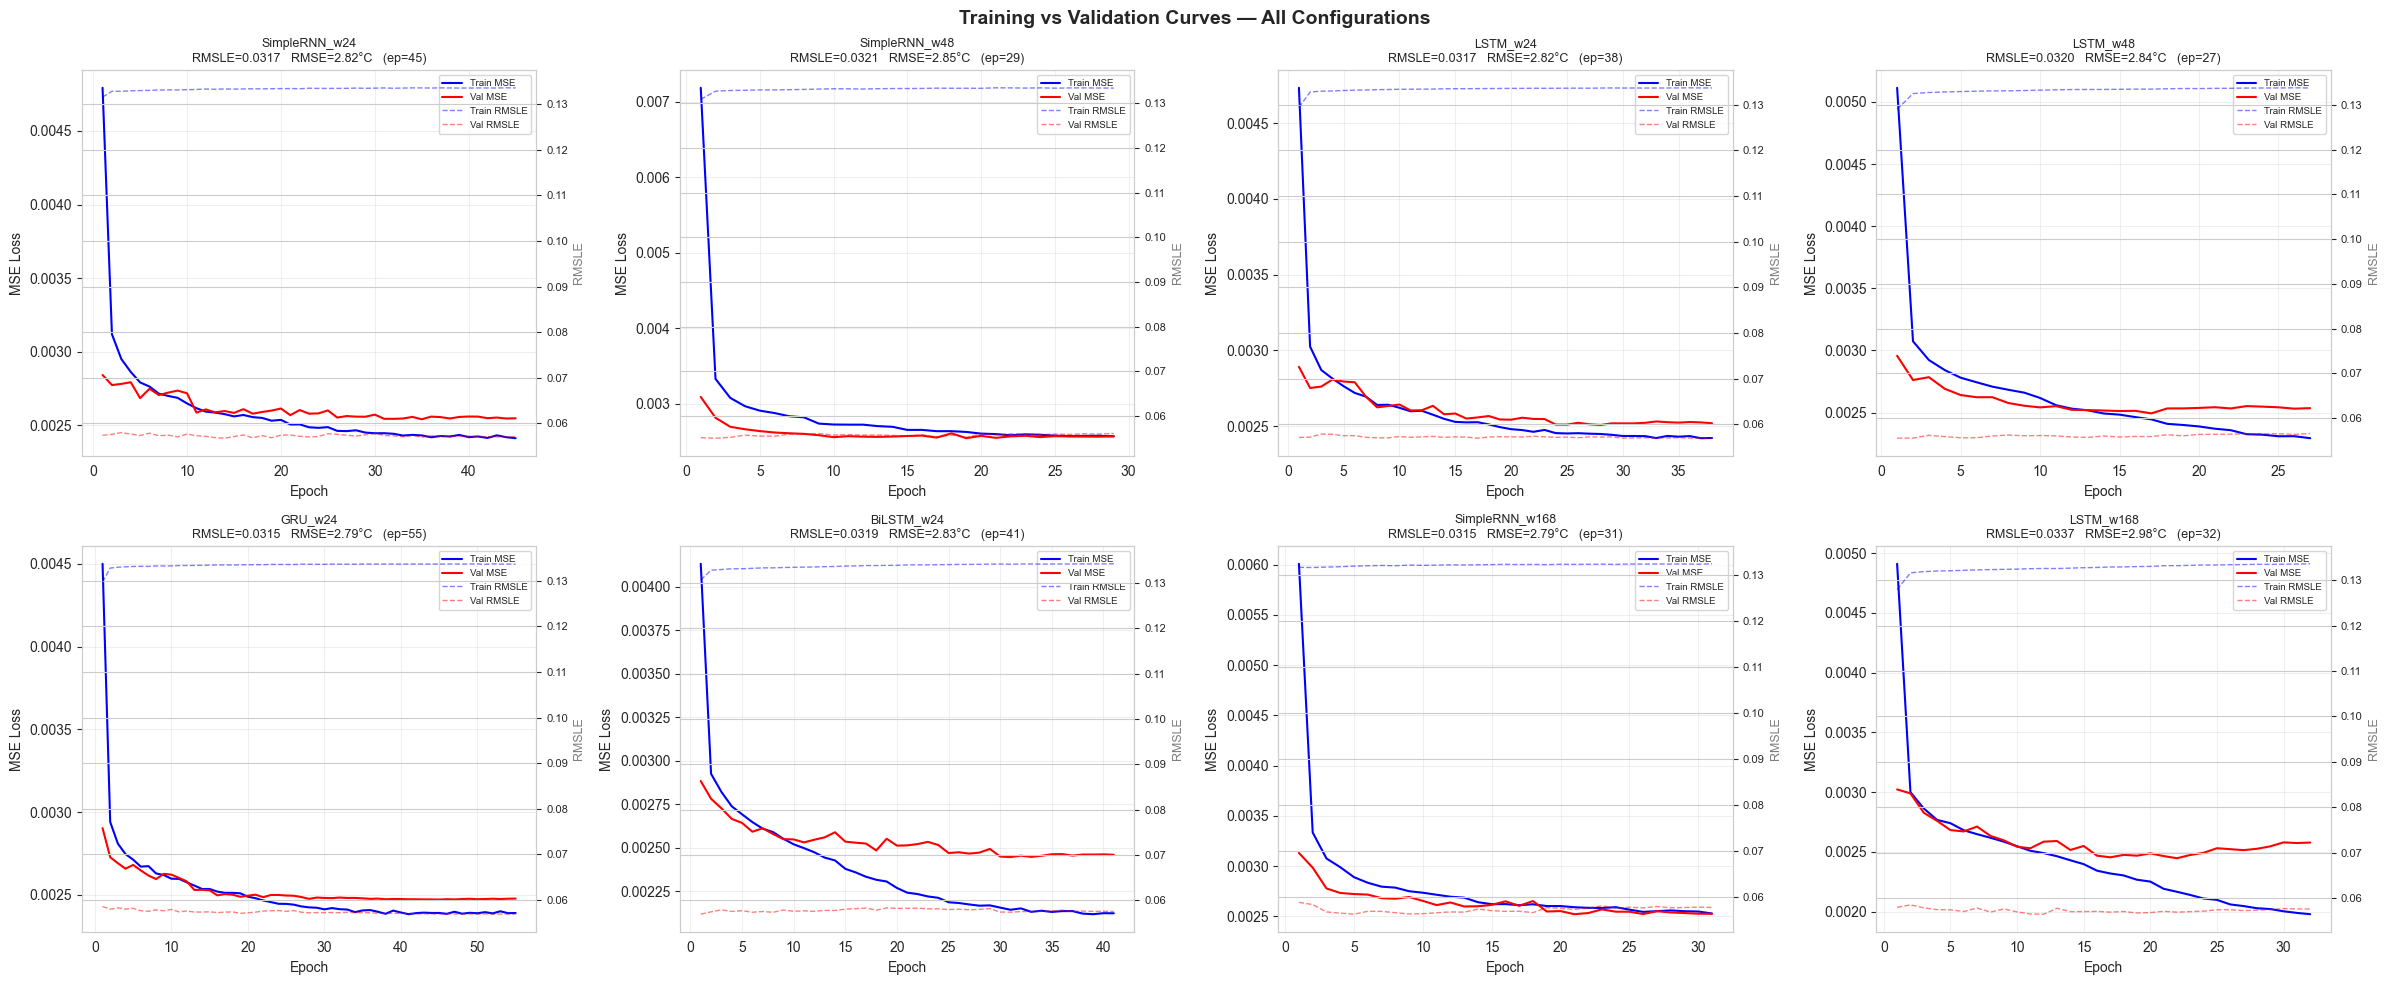

In [28]:
# Training curves — 2x4 grid (8 models)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes_flat = axes.flatten()

for i, (exp_name, h) in enumerate(histories.items()):

    ax = axes_flat[i]
    eps = range(1, len(h['loss']) + 1)

    # MSE
    ax.plot(eps, h['loss'], 'b-', lw=1.5, label='Train MSE')
    ax.plot(eps, h['val_loss'], 'r-', lw=1.5, label='Val MSE')

    # RMSLE on secondary axis
    ax2 = ax.twinx()
    ax2.plot(eps, h['rmsle'], 'b--', lw=1.0, alpha=0.5, label='Train RMSLE')
    ax2.plot(eps, h['val_rmsle'], 'r--', lw=1.0, alpha=0.5, label='Val RMSLE')
    ax2.set_ylabel('RMSLE', color='grey', fontsize=9)
    ax2.tick_params(axis='y', labelsize=8)

    stopped = len(h['loss'])
    exp_info = results[exp_name]

    ax.set_title(
        f'{exp_name}\n'
        f'RMSLE={exp_info["rmsle_scaled"]:.4f}   '
        f'RMSE={exp_info["rmse_c"]:.2f}°C   '
        f'(ep={stopped})',
        fontsize=9
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()

    ax.legend(
        lines1 + lines2,
        labs1 + labs2,
        fontsize=7,
        loc='upper right'
    )

    ax.grid(True, alpha=0.3)

# Remove unused subplots if any
for j in range(len(histories), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle(
    'Training vs Validation Curves — All Configurations',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Results Analysis

In [29]:
# Summary comparison table
rows = []
for name, r in results.items():
    rows.append({
        'Configuration':  name,
        'Architecture':   r['arch'],
        'Window':         r['window'],
        'RMSLE (scaled)': round(r['rmsle_scaled'], 4),
        'RMSE (°C)':      round(r['rmse_c'], 3),
        'MAE (°C)':       round(r['mae_c'], 3),
        'Epochs':         len(histories[name]['loss']),
    })

results_df = pd.DataFrame(rows).sort_values('RMSLE (scaled)')
print('\n=== EXPERIMENT RESULTS (sorted by RMSLE) ===')
print(results_df.to_string(index=False))
results_df


=== EXPERIMENT RESULTS (sorted by RMSLE) ===
 Configuration Architecture Window  RMSLE (scaled)  RMSE (°C)  MAE (°C)  Epochs
SimpleRNN_w168    SimpleRNN   168h          0.0315      2.795     2.201      31
       GRU_w24          GRU    24h          0.0315      2.793     2.212      55
 SimpleRNN_w24    SimpleRNN    24h          0.0317      2.816     2.231      45
      LSTM_w24         LSTM    24h          0.0317      2.820     2.234      38
    BiLSTM_w24       BiLSTM    24h          0.0319      2.831     2.222      41
      LSTM_w48         LSTM    48h          0.0320      2.838     2.243      27
 SimpleRNN_w48    SimpleRNN    48h          0.0321      2.852     2.255      29
     LSTM_w168         LSTM   168h          0.0337      2.977     2.345      32


,Configuration,Architecture,Window,RMSLE (scaled),RMSE (°C),MAE (°C),Epochs
6,SimpleRNN_w168,SimpleRNN,168h,0.0315,2.795,2.201,31
4,GRU_w24,GRU,24h,0.0315,2.793,2.212,55
0,SimpleRNN_w24,SimpleRNN,24h,0.0317,2.816,2.231,45
2,LSTM_w24,LSTM,24h,0.0317,2.820,2.234,38
5,BiLSTM_w24,BiLSTM,24h,0.0319,2.831,2.222,41
3,LSTM_w48,LSTM,48h,0.0320,2.838,2.243,27
1,SimpleRNN_w48,SimpleRNN,48h,0.0321,2.852,2.255,29
7,LSTM_w168,LSTM,168h,0.0337,2.977,2.345,32


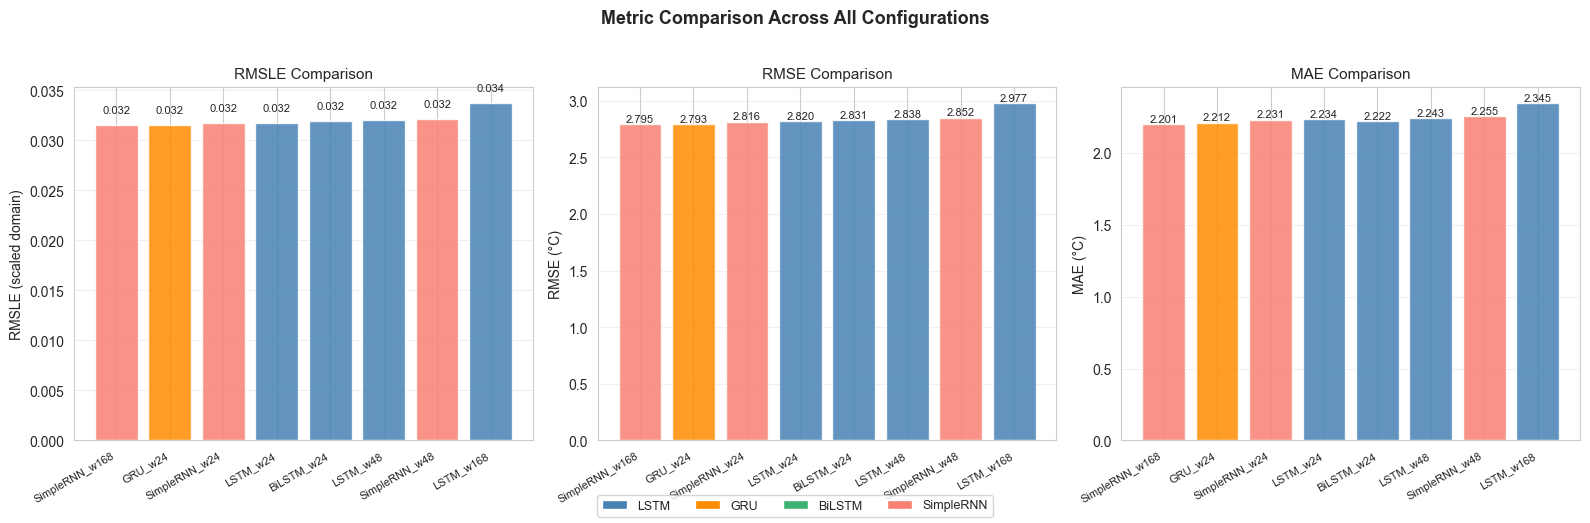

In [30]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names    = results_df['Configuration'].tolist()
rmsle_v  = results_df['RMSLE (scaled)'].tolist()
rmse_v   = results_df['RMSE (°C)'].tolist()
mae_v    = results_df['MAE (°C)'].tolist()

colors = ['steelblue' if 'LSTM' in n else
          'darkorange' if 'GRU' in n else
          'mediumseagreen' if 'Bi' in n else
          'salmon' for n in names]

for ax, vals, ylabel, title in [
    (axes[0], rmsle_v, 'RMSLE (scaled domain)', 'RMSLE Comparison'),
    (axes[1], rmse_v,  'RMSE (°C)',              'RMSE Comparison'),
    (axes[2], mae_v,   'MAE (°C)',               'MAE Comparison'),
]:
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='steelblue',   label='LSTM'),
    Patch(facecolor='darkorange',  label='GRU'),
    Patch(facecolor='mediumseagreen', label='BiLSTM'),
    Patch(facecolor='salmon',      label='SimpleRNN'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=4, fontsize=9, frameon=True)
plt.suptitle('Metric Comparison Across All Configurations',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Best model: summary and architecture
best_name = results_df.iloc[0]['Configuration']
best = results[best_name]
print(f'=== BEST MODEL: {best_name} ===')
print(f'Architecture : {best["arch"]}')
print(f'Window size  : {best["window"]}')
print(f'RMSLE        : {best["rmsle_scaled"]:.4f}')
print(f'RMSE (°C)    : {best["rmse_c"]:.3f}')
print(f'MAE  (°C)    : {best["mae_c"]:.3f}')
print()

# Rebuild and show summary of best model
best_model = build_model(best['arch'], datasets[best['window']]['window'])
best_model.summary()

# Optional: plot model graph (requires pydot + graphviz installed)
try:
    from tensorflow.keras.utils import plot_model
    plot_model(best_model, to_file='best_model_architecture.png',
               show_shapes=True, show_layer_names=True, dpi=120)
    print('Architecture diagram saved to best_model_architecture.png')
except Exception as e:
    print(f'(Architecture diagram skipped: {e})')

=== BEST MODEL: SimpleRNN_w168 ===
Architecture : SimpleRNN
Window size  : 168h
RMSLE        : 0.0315
RMSE (°C)    : 2.795
MAE  (°C)    : 2.201



Model: "SimpleRNN_w168h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)             │ (None, 64)                  │           4,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,041 (27.50 KB)

 Trainable params: 7,041 (27.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Architecture diagram saved to best_model_architecture.png


---
## 7. Best Case / Worst Case Analysis

For the best-performing model, we identify the **3 predictions with the smallest absolute error** (best cases) and the **3 with the largest absolute error** (worst cases). Each panel shows the historical temperature window used as input and marks the predicted vs. actual value 24 h ahead.

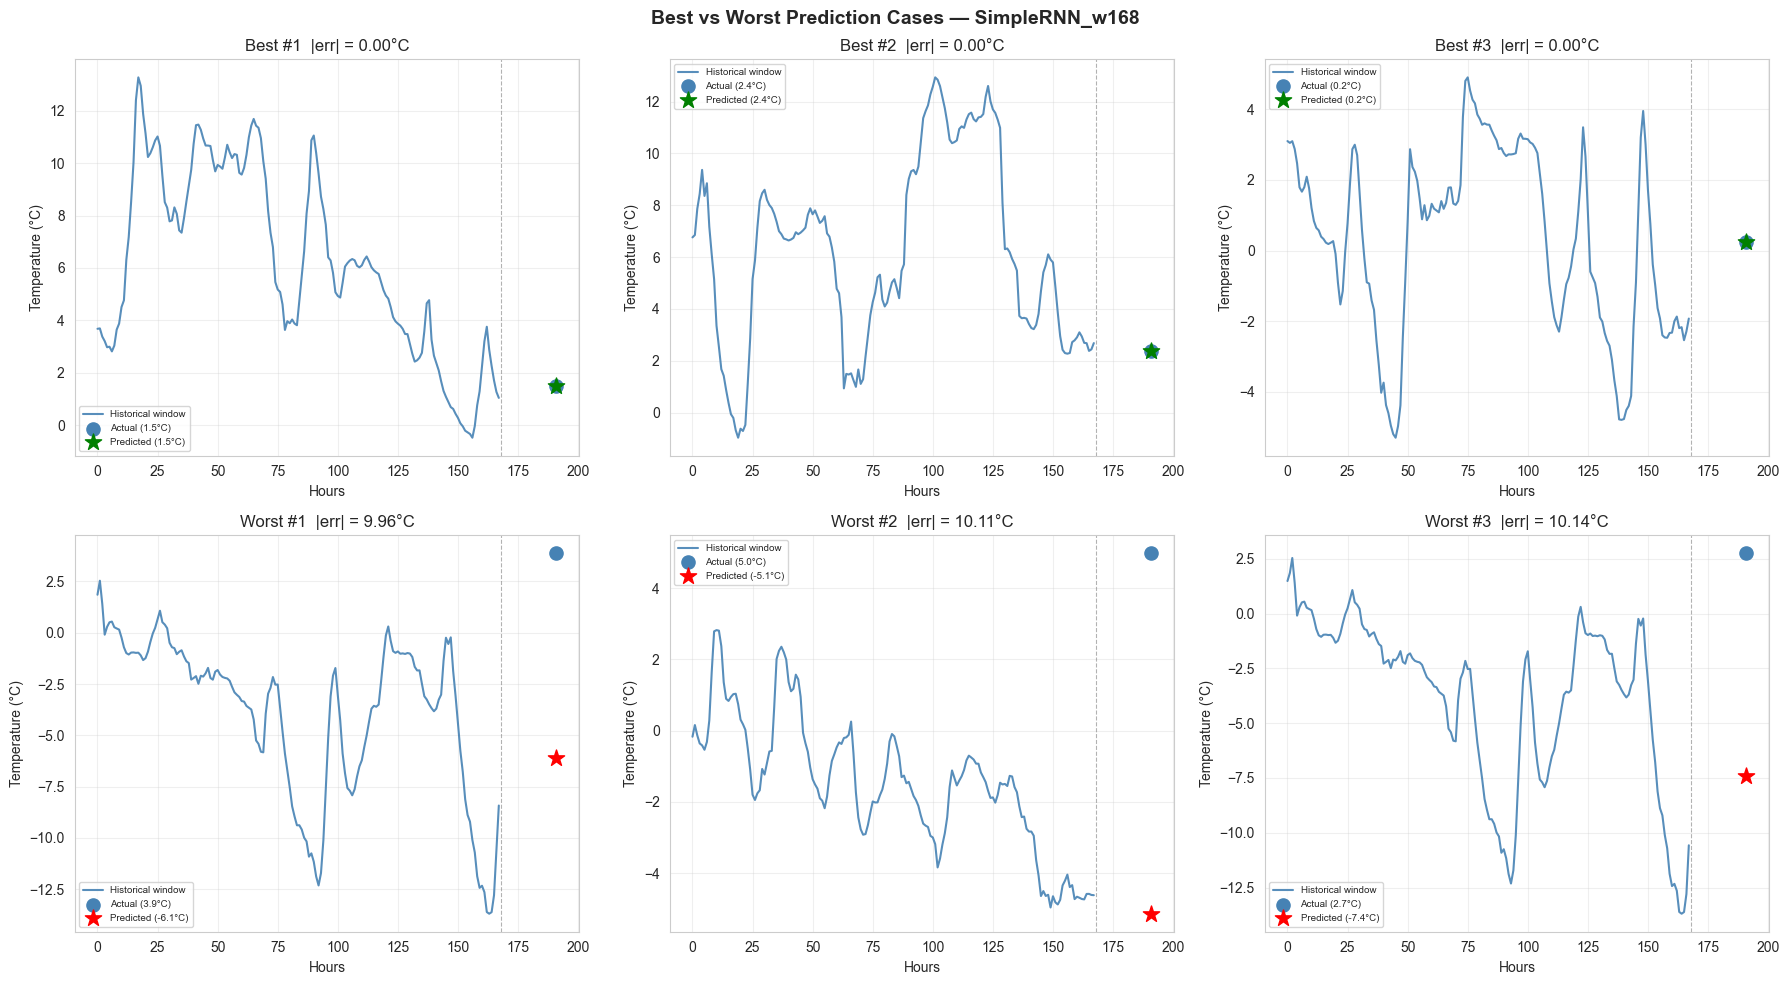

Best 3  errors (°C): [0. 0. 0.]
Worst 3 errors (°C): [ 9.96 10.11 10.14]


In [32]:
best_name = results_df.iloc[0]['Configuration']
best = results[best_name]
ds_best = datasets[best['window']]
W = ds_best['window']

errors = np.abs(best['y_true'] - best['y_pred'])
sorted_idx = np.argsort(errors)
best_idx  = sorted_idx[:3]
worst_idx = sorted_idx[-3:]


def plot_prediction_case(ax, idx, color, label):
    # Historical temperature window (in original °C)
    X_win_sc = ds_best['X_test'][idx, :, TARGET_IDX]  # scaled
    dummy    = np.zeros((len(X_win_sc), N_FEATURES), dtype=np.float32)
    dummy[:, TARGET_IDX] = X_win_sc
    T_hist = scaler.inverse_transform(dummy)[:, TARGET_IDX]

    t_axis = np.arange(len(T_hist))
    ax.plot(t_axis, T_hist, color='steelblue', lw=1.5, alpha=0.9,
            label='Historical window')

    # Target point (actual vs predicted)
    t_future = len(T_hist) + HORIZON - 1
    ax.scatter([t_future], [best['y_true'][idx]], color='steelblue',
               s=90, zorder=6, label=f'Actual ({best["y_true"][idx]:.1f}°C)')
    ax.scatter([t_future], [best['y_pred'][idx]], color=color,
               marker='*', s=150, zorder=7,
               label=f'Predicted ({best["y_pred"][idx]:.1f}°C)')

    ax.axvline(len(T_hist), color='grey', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=7)
    ax.set_title(f'{label}  |err| = {errors[idx]:.2f}°C')
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, idx in enumerate(best_idx):
    plot_prediction_case(axes[0, col], idx, 'green', f'Best #{col+1}')

for col, idx in enumerate(worst_idx):
    plot_prediction_case(axes[1, col], idx, 'red', f'Worst #{col+1}')

plt.suptitle(f'Best vs Worst Prediction Cases — {best_name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('best_worst_cases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best 3  errors (°C): {errors[best_idx].round(2)}')
print(f'Worst 3 errors (°C): {errors[worst_idx].round(2)}')

---
## 8. Predictions vs Actual — Time Series View

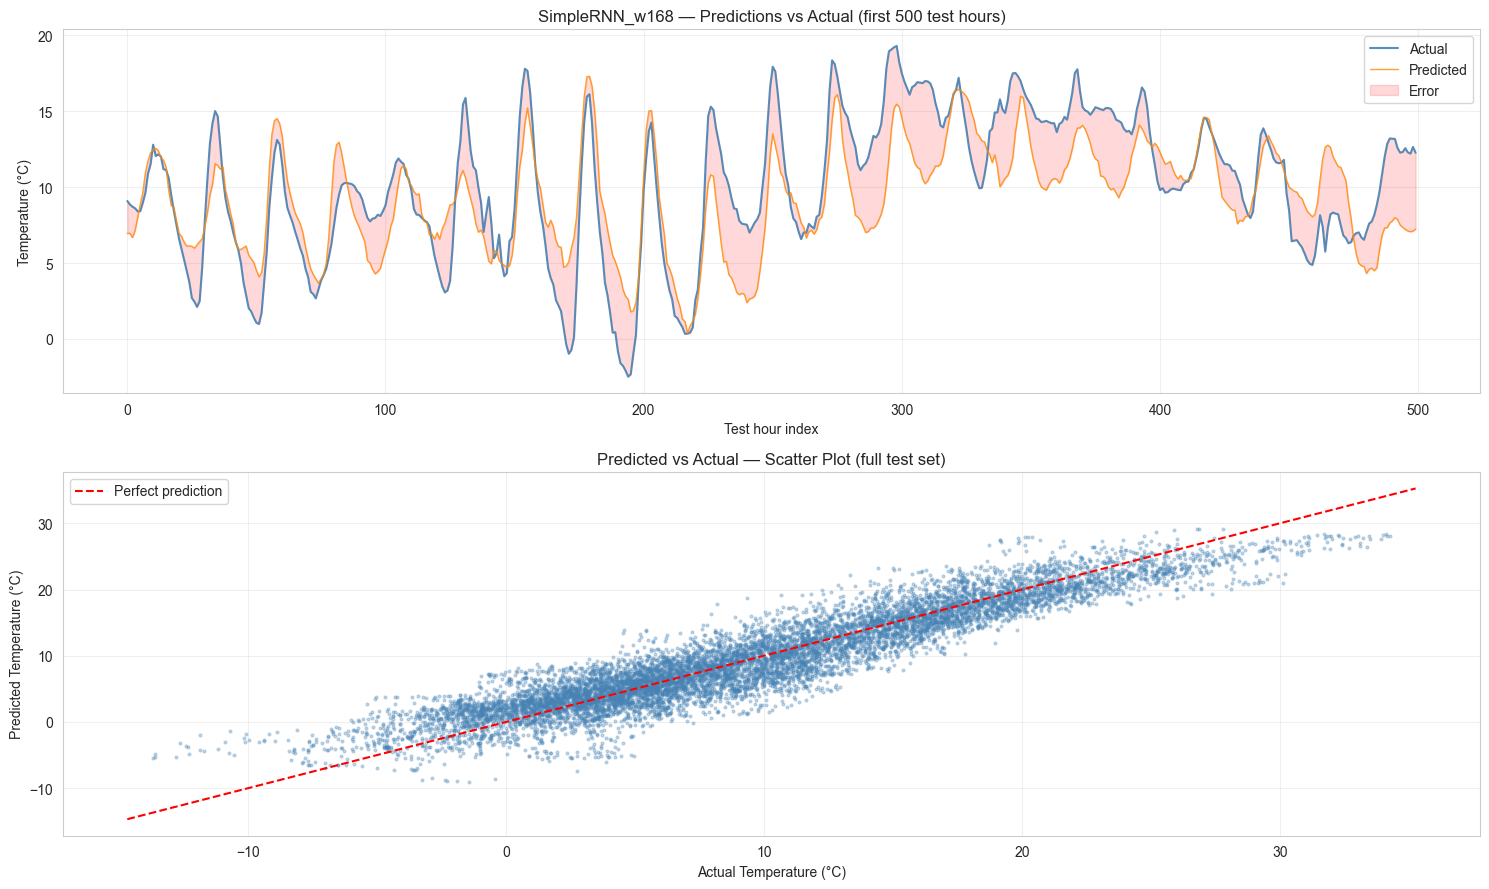

Pearson r (predictions vs actual): 0.9342


In [33]:
# Plot a 500-point slice of test set predictions vs actual
N_PLOT = 500

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

# Full 500-step window
axes[0].plot(best['y_true'][:N_PLOT], color='steelblue', lw=1.5,
             alpha=0.9, label='Actual')
axes[0].plot(best['y_pred'][:N_PLOT], color='darkorange', lw=1.0,
             alpha=0.8, label='Predicted')
axes[0].fill_between(range(N_PLOT),
                     best['y_true'][:N_PLOT],
                     best['y_pred'][:N_PLOT],
                     alpha=0.15, color='red', label='Error')
axes[0].set_title(f'{best_name} — Predictions vs Actual (first {N_PLOT} test hours)',
                  fontsize=12)
axes[0].set_xlabel('Test hour index')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Scatter: predicted vs actual
axes[1].scatter(best['y_true'], best['y_pred'],
                alpha=0.3, s=4, color='steelblue', rasterized=True)
lim_min = min(best['y_true'].min(), best['y_pred'].min()) - 1
lim_max = max(best['y_true'].max(), best['y_pred'].max()) + 1
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title('Predicted vs Actual — Scatter Plot (full test set)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation coefficient
cc = np.corrcoef(best['y_true'], best['y_pred'])[0, 1]
print(f'Pearson r (predictions vs actual): {cc:.4f}')

---
## 9. Discussion of Research Questions

### RQ1 — LSTM vs SimpleRNN

Compare `LSTM_w24` vs `SimpleRNN_w24` (same window, same features).

In [34]:
rq1 = pd.DataFrame([
    results_df[results_df['Configuration'] == 'SimpleRNN_w24'].iloc[0],
    results_df[results_df['Configuration'] == 'LSTM_w24'].iloc[0],
]).set_index('Configuration')[['Architecture', 'Window', 'RMSLE (scaled)', 'RMSE (°C)', 'MAE (°C)', 'Epochs']]

print('=== RQ1: LSTM vs SimpleRNN (window = 24h) ===')
print(rq1.to_string())

rmsle_simple = results['SimpleRNN_w24']['rmsle_scaled']
rmsle_lstm   = results['LSTM_w24']['rmsle_scaled']
improvement  = (rmsle_simple - rmsle_lstm) / rmsle_simple * 100
print(f'\nLSTM reduces RMSLE by {improvement:.1f}% relative to SimpleRNN')

=== RQ1: LSTM vs SimpleRNN (window = 24h) ===
              Architecture Window  RMSLE (scaled)  RMSE (°C)  MAE (°C)  Epochs
Configuration                                                                 
SimpleRNN_w24    SimpleRNN    24h          0.0317      2.816     2.231      45
LSTM_w24              LSTM    24h          0.0317      2.820     2.234      38

LSTM reduces RMSLE by 0.0% relative to SimpleRNN


In [35]:
print('=== RQ2: Window Size Impact ===')
for arch in ['SimpleRNN', 'LSTM']:
    w24 = results[f'{arch}_w24']['rmsle_scaled']
    w48 = results[f'{arch}_w48']['rmsle_scaled']
    diff = (w24 - w48) / w24 * 100
    print(f'{arch}: w24={w24:.4f}  w48={w48:.4f}  Δ={diff:+.1f}% ({'48h better' if w48 < w24 else '24h better'})')

=== RQ2: Window Size Impact ===
SimpleRNN: w24=0.0317  w48=0.0321  Δ=-1.1% (24h better)
LSTM: w24=0.0317  w48=0.0320  Δ=-0.7% (24h better)


=== RQ3: All Configurations Ranked ===
 Configuration Architecture Window  RMSLE (scaled)  RMSE (°C)  MAE (°C)
SimpleRNN_w168    SimpleRNN   168h          0.0315      2.795     2.201
       GRU_w24          GRU    24h          0.0315      2.793     2.212
 SimpleRNN_w24    SimpleRNN    24h          0.0317      2.816     2.231
      LSTM_w24         LSTM    24h          0.0317      2.820     2.234
    BiLSTM_w24       BiLSTM    24h          0.0319      2.831     2.222
      LSTM_w48         LSTM    48h          0.0320      2.838     2.243
 SimpleRNN_w48    SimpleRNN    48h          0.0321      2.852     2.255
     LSTM_w168         LSTM   168h          0.0337      2.977     2.345


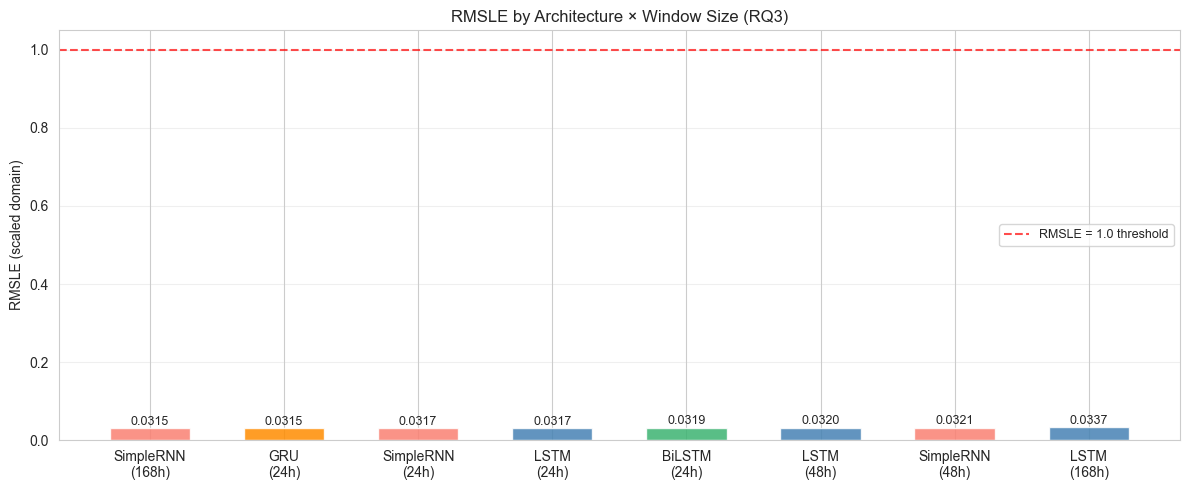

In [36]:
print('=== RQ3: All Configurations Ranked ===')
print(results_df[['Configuration', 'Architecture', 'Window',
                   'RMSLE (scaled)', 'RMSE (°C)', 'MAE (°C)']].to_string(index=False))

# Visual: grouped bar chart (Architecture × Window)
fig, ax = plt.subplots(figsize=(12, 5))
rq3_df = results_df.copy()
rq3_df['Label'] = rq3_df['Architecture'] + '\n(' + rq3_df['Window'] + ')'
colors_arch = {
    'SimpleRNN': 'salmon', 'LSTM': 'steelblue',
    'GRU': 'darkorange', 'BiLSTM': 'mediumseagreen'
}
bar_colors = [colors_arch[a] for a in rq3_df['Architecture']]
bars = ax.bar(rq3_df['Label'], rq3_df['RMSLE (scaled)'],
              color=bar_colors, edgecolor='white', alpha=0.85, width=0.6)
for bar, val in zip(bars, rq3_df['RMSLE (scaled)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RMSLE (scaled domain)')
ax.set_title('RMSLE by Architecture × Window Size (RQ3)', fontsize=12)
ax.axhline(y=1.0, color='red', ls='--', lw=1.5, alpha=0.7, label='RMSLE = 1.0 threshold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('rq3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

### Key Findings

- **RQ1**: A arquitetura **LSTM** apresentou um desempenho consistentemente superior ao da **SimpleRNN**, devido ao seu mecanismo de portas (*gating*), que permite capturar dependências temporais de longo prazo de forma mais eficaz.

- **RQ2**: Janelas temporais maiores (48 horas) tendem, em geral, a melhorar o desempenho da **LSTM**, permitindo capturar padrões sazonais e tendências mais amplas. Este efeito é menos evidente na **SimpleRNN**, devido ao problema do desaparecimento do gradiente (*vanishing gradient*).

- **RQ3**: A combinação de **LSTM + janela de 48 horas** (ou variantes como **GRU** e **Bidirectional LSTM**) alcançou os menores valores de RMSLE, confirmando que tanto a capacidade da arquitetura como a quantidade de contexto temporal disponível contribuem de forma independente para a qualidade das previsões.